# Practical Recommendations for Gradient-Based Training of Deep Architectures — Summary

# https://arxiv.org/pdf/1206.5533

## Abstract
This chapter by Yoshua Bengio (2012) presents a practical guide to hyper-parameter selection and training practices for gradient-based learning of deep neural networks, including auto-encoder variants (denoising and contractive auto-encoders). It synthesizes empirically validated recommendations from years of research practice, covering learning rate schedules, mini-batch sizes, regularization, initialization schemes, and debugging tools, while also discussing open questions regarding the difficulty of training deep architectures.

## Problems
- Deep learning algorithms involve numerous hyper-parameters (often ten or more), making manual tuning unwieldy and non-reproducible.
- Many practical recommendations in the field are based on experimentation and heuristics rather than rigorous theoretical or comparative validation.
- Deeper architectures appear empirically harder to train than shallow ones, with a higher risk of poor local minima from random initialization.
- Grid search for hyper-parameter optimization scales exponentially with the number of hyper-parameters, becoming computationally intractable beyond 2–3 parameters.
- Gradient-based optimization of non-convex, highly non-linear objectives is sensitive to learning rate, initialization, and regularization choices, with unclear interactions among them.

## Proposed Solutions
- **Random search** over grid search for hyper-parameter optimization, since it explores more distinct values per hyper-parameter and scales better when only a subset of hyper-parameters matters.
- **Greedy layer-wise hyper-parameter optimization** (Algorithm 1) for architectures with unsupervised pre-training, selecting hyper-parameters for each layer sequentially using cheap validation proxies.
- **Coordinate descent and multi-resolution search** for manual hyper-parameter tuning when computational resources are limited.
- Concrete initialization formulas (e.g., $$r = \sqrt{6/(\text{fan-in}+\text{fan-out})}$$ for tanh units) to avoid symmetry-breaking and vanishing/exploding activations.
- Gradient checking via finite-difference approximation, including a second-order formula $$\frac{\partial f(x)}{\partial x} \approx \frac{f(x+\varepsilon)-f(x-\varepsilon)}{2\varepsilon} + o(\varepsilon^2)$$ for verifying backpropagation correctness.
- Use of flow graphs and automatic/symbolic differentiation (e.g., Theano) to structure gradient computation reliably and efficiently.

## Purpose
The chapter aims to consolidate practical, empirically grounded guidance for researchers and practitioners training deep multi-layer neural networks and auto-encoder-based unsupervised models, reducing reliance on ad hoc tuning and improving reproducibility of results across research groups.

## Methodology
The paper is expository and prescriptive rather than experimental in the traditional sense; it reviews and consolidates prior findings across several methodological areas:

- **Optimization fundamentals**: stochastic gradient descent (SGD),
$$\theta^{(t)} \leftarrow \theta^{(t-1)} - \epsilon_t \frac{\partial L(z_t,\theta)}{\partial \theta}$$
mini-batch gradient descent,
$$\theta^{(t)} \leftarrow \theta^{(t-1)} - \epsilon_t \frac{1}{B}\sum_{t'=Bt+1}^{B(t+1)} \frac{\partial L(z_{t'},\theta)}{\partial \theta}$$
and learning rate scheduling, e.g., $$\epsilon_t = \frac{\epsilon_0 \tau}{\max(t,\tau)}$$.
- **Hyper-parameter taxonomy**: separates optimization hyper-parameters (learning rate, mini-batch size, momentum, number of iterations) from model/criterion hyper-parameters (number of hidden units, weight decay coefficient $$\lambda$$, sparsity coefficient $$\alpha$$, non-linearity choice, weight initialization scale).
- **Regularization**: L1/L2 penalties with Bayesian interpretation as negative log-priors, and activation sparsity penalties (L1 norm, KL-divergence to a target sparsity $$\rho$$).
- **Search strategies**: comparison of grid search, random search, coordinate descent, and layer-wise greedy optimization.
- **Debugging methodology**: gradient checking, overfitting sanity checks on small datasets, buffer initialization to NaN for bug detection, and visualization techniques (filter visualization, t-SNE, Hinton diagrams, learning trajectory visualization).
- **Computational practices**: use of BLAS libraries, multi-core parallelism, and GPU acceleration (reporting 4× to 40× speedups on 512-core machines).

## Results
- Random search was found to be substantially more efficient than grid search once the number of hyper-parameters exceeds 2–3, and it preserves parallelizability without wasting computation on failed jobs.
- The learning rate was consistently identified as the single most influential hyper-parameter across datasets and architectures.
- Larger-than-optimal hidden layer sizes tend not to hurt generalization significantly, given proper regularization and early stopping, though they increase computational cost.
- Unsupervised pre-training generally helps and rarely hurts, with the effect being more pronounced (and more hidden units beneficial) when combined with supervised fine-tuning.
- Rectifying non-linearities and softsign functions outperformed sigmoids in deep supervised networks lacking unsupervised pre-training, while symmetric non-linearities like tanh avoided the plateau issues sigmoids exhibited.
- Early stopping was shown to be an effective and computationally cheap regularizer, often reducing the need for separate L2 regularization.
- Visualization studies (e.g., Erhan et al., cited within) demonstrated that different random initializations converge to distinct effective local minima, with pre-trained and randomly initialized networks landing in qualitatively different regions of function space.

## Conclusions
The chapter concludes that while deep learning training practice has matured considerably, with well-tested heuristics for hyper-parameter ranges, initialization, and regularization, substantial open questions remain regarding why deeper architectures are harder to optimize. It highlights local training signals, proper initialization scaling, and non-linearity choice as practical factors mitigating this difficulty, and calls for continued theoretical and empirical work—particularly in automated hyper-parameter optimization and second-order/adaptive learning rate methods—to further reduce the reliance on manual tuning in deep architecture training.

# Mathematical and Statistical Content Summary

## 1. Loss Gradient for a Single Example
$$\hat{g} = \frac{\partial L(z,\theta)}{\partial \theta}$$
The gradient of the loss $L$ for one example $z$ with respect to parameters $\theta$. This is the basic quantity used to update model parameters in gradient-based learning.

## 2. Generalization Error as an Expectation
$$C = E[L(z,\theta)] = \int p(z)L(z,\theta)\,dz$$
The true objective of learning is not training error but the expected loss over the unknown data distribution $p(z)$. This formalizes "generalization error" as the quantity a learner truly wants to minimize.

## 3. Unbiasedness of the Stochastic Gradient
$$\frac{\partial C}{\partial \theta} = \int p(z)\frac{\partial L(z,\theta)}{\partial \theta}\,dz = E[\hat{g}]$$
Shows that the gradient computed from a single random example is, in expectation, equal to the gradient of the true generalization error. This is the theoretical justification for why online/stochastic gradient descent is a valid optimization strategy even though it only sees one example (or mini-batch) at a time.

## 4. Online (Stochastic) Gradient Descent Update
$$\theta^{(t)} \leftarrow \theta^{(t-1)} - \epsilon_t \frac{\partial L(z_t,\theta)}{\partial \theta}$$
The basic parameter update rule: subtract a scaled gradient from the current parameters. $\epsilon_t$ is the learning rate, a hyper-parameter controlling step size. Central algorithm for training neural networks.

## 5. Mini-Batch Gradient Descent
$$\theta^{(t)} \leftarrow \theta^{(t-1)} - \epsilon_t \frac{1}{B}\sum_{t'=Bt+1}^{B(t+1)} \frac{\partial L(z_{t'},\theta)}{\partial \theta} \quad (1)$$
Generalizes SGD by averaging gradients over $B$ examples before updating. $B=1$ recovers pure online SGD; $B=$ training set size recovers full batch gradient descent. Intermediate $B$ trades off computational efficiency (via matrix-matrix operations) against convergence speed (fewer updates per epoch).

## 6. Learning Rate Schedule
$$\epsilon_t = \frac{\epsilon_0 \tau}{\max(t,\tau)} \quad (2)$$
A decay schedule keeping the learning rate constant at $\epsilon_0$ for the first $\tau$ steps, then decreasing proportionally to $1/t$. $\tau$ is a hyper-parameter controlling when decay begins.

## 7. Chain Rule for Gradient Computation (Flow Graph Backpropagation)
$$g_a = \sum_s g_s \frac{\partial o_s}{\partial o_a}$$
For a node $a$ in a computational (flow) graph with output $o_a$, its gradient $g_a = \partial L/\partial o_a$ is computed by summing contributions from all successor nodes $s$, weighted by local partial derivatives. This is the mathematical basis of automatic differentiation/backpropagation. The recursion is initialized at the output with $g_L = \partial L/\partial L = 1$.

## 8. Reconstruction Loss Functions (Auto-Encoders)
- Squared error (real-valued inputs): $$\|x - r(x)\|^2$$
- Cross-entropy (binary inputs): $$-\sum_i x_i \log r_i(x) + (1-x_i)\log(1-r_i(x))$$
These measure how well an auto-encoder's reconstruction $r(x)$ matches the input $x$. Minimizing them trains the encoder/decoder pair to capture the structure of the input distribution.

## 9. Contractive Auto-Encoder (CAE) Penalty
$$\left\|\frac{\partial f(x)}{\partial x}\right\|^2$$
The squared Frobenius norm of the encoder's Jacobian, added to the training criterion. It penalizes sensitivity of the learned representation $f(x)$ to small input perturbations, encouraging robustness (contraction) around training examples.

## 10. Finite-Difference Gradient Approximation
First-order: $$\frac{\partial f(x)}{\partial x} = \frac{f(x+\varepsilon)-f(x)}{\varepsilon} + o(\varepsilon)$$
Second-order (centered): $$\frac{\partial f(x)}{\partial x} \approx \frac{f(x+\varepsilon)-f(x-\varepsilon)}{2\varepsilon} + o(\varepsilon^2)$$
Used to numerically verify analytically/automatically computed gradients. The centered formula cancels second-order Taylor terms, giving quadratically better precision at twice the computational cost — a practical debugging tool rather than a training method.

## 11. L2 (Weight Decay) Regularization
$$\lambda \sum_i \theta_i^2$$
Penalizes large parameter values, corresponding to a Gaussian prior on parameters:
$$\propto \exp\left(-\frac{1}{2}\frac{\|\theta\|^2}{\sigma^2}\right), \quad \sigma^2 = \frac{1}{2\lambda}$$
Reduces model capacity and overfitting by shrinking weights toward zero.

## 12. L1 Regularization
$$\lambda \sum_i |\theta_i|$$
Corresponds to a Laplace prior on parameters:
$$\propto e^{-|\theta|/s}, \quad s = \frac{1}{\lambda}$$
Encourages sparsity (many parameters driven near exactly zero), acting as an implicit feature selector, unlike L2 which shrinks but rarely zeroes out parameters.

## 13. Bayesian Interpretation of Regularization
$$-\log P(data,\theta) = -\log P(data|\theta) - \log P(\theta)$$
The regularization term is interpreted as the negative log-prior $-\log P(\theta)$, and the total training criterion as the negative joint log-likelihood of data and parameters. This connects regularized loss minimization to Maximum A Posteriori (MAP) estimation.

## 14. Sparsity-Inducing Penalty on Hidden Activations (KL Divergence Form)
$$-\rho \log \bar{h}_j - (1-\rho)\log(1-\bar{h}_j) + \text{constant}$$
A Kullback-Leibler divergence between the average hidden unit activation $\bar{h}_j$ (treated as a probability) and a target sparsity level $\rho$ (e.g., 0.05). Encourages most hidden units to be inactive most of the time, promoting sparse, disentangled representations.

## 15. Student-t Sparsity Penalty
$$\log(1+h_j^2)$$
An alternative sparsity-inducing penalty on hidden unit activations, originating from sparse coding, used as a smoother alternative to the L1 penalty.

## 16. Weight Initialization Scaling (Glorot-Bengio Formula)
$$r = \sqrt{\frac{6}{\text{fan-in}+\text{fan-out}}} \quad \text{(tanh units)}$$
$$r = 4\sqrt{\frac{6}{\text{fan-in}+\text{fan-out}}} \quad \text{(sigmoid units)}$$
Weights are sampled from $\text{Uniform}(-r, r)$. This scaling is derived to keep the variance of activations and gradients approximately stable across layers, preventing vanishing or exploding signals in deep networks. "Fan-in"/"fan-out" refer to the number of incoming/outgoing connections of a unit.

## 17. Neuron Non-linearities
- Sigmoid: $$s(a) = \frac{1}{1+e^{-a}}$$
- Hyperbolic tangent: $$s(a) = \frac{e^a - e^{-a}}{e^a + e^{-a}}$$
- Rectifier: $$s(a) = \max(0,a)$$
- Softsign: $$s(a) = \frac{a}{1+|a|}$$
These are activation functions applied to a neuron's weighted input $a = w'x+b$. Their mathematical shape (saturating vs. non-saturating, symmetric vs. asymmetric) affects how well gradients propagate through deep networks.

## 18. Momentum (Gradient Smoothing)
$$\bar{g} \leftarrow (1-\beta)\bar{g} + \beta g$$
An exponential moving average of past gradients $g$, controlled by coefficient $\beta$. Using $\bar{g}$ instead of the instantaneous gradient $g$ in the update rule smooths out oscillations in directions of high curvature, often accelerating convergence.

## 19. Model Capacity/Bias-Variance Decomposition (Referenced)
$$C = \text{bias}^2 + \text{variance}$$ (conceptually referenced, e.g., via Geman et al. 1992)
Generalization mean squared error decomposes into a bias term and a variance term. Parameter sharing (reuse) is motivated as reducing variance by effectively increasing the number of examples informing each shared parameter.

## Summary of Role in the Paper
These mathematical tools collectively support three purposes in the paper:
1. **Optimization theory** (items 1–6, 18) — justifying and formalizing stochastic gradient descent as the core training algorithm.
2. **Computational mechanics** (items 7, 10) — enabling correct and efficient computation of gradients via automatic differentiation and validating them via finite differences.
3. **Model specification and regularization** (items 8–9, 11–17) — defining loss functions, priors, and architectural choices (initialization, non-linearities) that shape what the network learns and how well it generalizes.

# Key Problems, Limitations, and Proposed Solutions

| # | Problem / Research Gap | How This Limits Prior Work | Proposed Solution in the Paper |
|---|------------------------|------------------------------|----------------------------------|
| 1 | Deep learning algorithms involve a large number of hyper-parameters (often ten or more), each requiring careful tuning. | Manual tuning is time-consuming, unappealing, and inconsistent across research groups, reducing reproducibility of results. | Provides a structured taxonomy separating optimization hyper-parameters (learning rate, mini-batch size, momentum, iterations) from model/criterion hyper-parameters (hidden units, regularization coefficients, non-linearity), with concrete recommended ranges and defaults for each. |
| 2 | Many established training heuristics come from empirical practice without formal theoretical or comparative validation. | Different researchers and groups disagree on best practices, and recommendations may not generalize reliably across tasks. | Explicitly frames the recommendations as a "living practice" to be challenged and validated, while grounding them in documented experimental evidence and, where possible, mathematical justification (e.g., Bayesian interpretation of regularization). |
| 3 | Grid search for hyper-parameter optimization scales exponentially with the number of hyper-parameters (e.g., $6^5 = 7776$ configurations for 5 hyper-parameters at 6 values each). | Infeasible to jointly search more than 2–3 hyper-parameters; wastes computation when only a subset of hyper-parameters actually matters. | Advocates random sampling of hyper-parameter configurations, shown to converge faster than grid search when only a few hyper-parameters are influential, while retaining full parallelizability. |
| 4 | In deep architectures with unsupervised pre-training, jointly optimizing hyper-parameters across all layers is computationally expensive. | Naively extending grid/random search to a multi-layer, multi-stage pipeline multiplies computational cost across layers. | Introduces a greedy layer-wise hyper-parameter optimization procedure (Algorithm 1) that selects near-optimal hyper-parameters for each layer sequentially using cheap validation proxies, then keeps only the K best configurations. |
| 5 | Deeper neural networks are empirically harder to train than shallow ones, with greater risk of poor local minima from random initialization. | Optimization difficulties in deep networks are often conflated with capacity/overfitting issues, obscuring the true source of poor performance. | Surveys empirical factors that mitigate this difficulty: local training signals (e.g., layer-wise pre-training), variance-preserving weight initialization (Glorot–Bengio formula), and choice of non-saturating non-linearities (rectifier, softsign). |
| 6 | Sigmoidal non-linearities cause optimization plateaus in deep supervised networks without unsupervised pre-training, due to saturation near 0 and gradient vanishing. | Naive use of sigmoid activations in deep nets leads to poor convergence and inferior generalization performance. | Recommends symmetric non-linearities (tanh) or non-saturating functions (rectifier, softsign) for hidden units, based on comparative studies showing improved gradient flow and credit assignment. |
| 7 | Distinguishing optimization failure from overfitting is difficult when test error is high, complicating diagnosis of training problems. | Without a systematic diagnostic approach, practitioners may misattribute poor test performance to the wrong cause (e.g., regularizing when the real issue is optimization). | Proposes comparing training error and test/validation error curves as a diagnostic tool, along with gradient checking and small-dataset overfitting sanity checks to isolate implementation bugs from genuine capacity/regularization issues. |
| 8 | Manual differentiation of gradients is error-prone, verbose, and lacks modularity, increasing the risk of silent bugs in training code. | Bugs in gradient computation can produce plausible-looking but incorrect training dynamics that are hard to detect. | Recommends structuring computation as a flow graph with modular forward/backward (fprop/bprop) operations and automatic/symbolic differentiation (e.g., Theano), combined with finite-difference gradient checking for verification. |
| 9 | Reconstruction-based unsupervised learning (auto-encoders, RBMs) is computationally expensive for sparse, high-dimensional inputs because reconstruction is computed over the full input space. | Standard auto-encoder training does not scale efficiently to sparse high-dimensional data (e.g., text, symbolic inputs). | Describes a sampled reconstruction approach (importance-sampling-based) that computes loss only over a sampled subset of reconstruction dimensions, reducing computation while remaining an unbiased estimator. |
| 10 | Learning rate is consistently the most influential hyper-parameter, yet no consensus exists on eliminating the need to tune it manually. | Requires costly manual or grid-based search for a well-performing learning rate schedule for each new task/architecture. | Discusses adaptive and second-order learning rate methods (e.g., diagonal Newton approximations, natural gradient, adagrad) as promising but not-yet-standardized alternatives to manual learning rate tuning. |

In [1]:
# ============================================================================
# EDUCATIONAL REPLICATION
# Paper: "Practical Recommendations for Gradient-Based Training of Deep
#         Architectures" (Yoshua Bengio, 2012)
#
# This paper is NOT a model-architecture paper. It is a PRACTICAL GUIDE on
# how to train deep neural networks well. We therefore build a small CNN
# classifier for CIFAR-10 and train it using the concrete recommendations
# described in the paper:
#   1. Mini-batch Stochastic Gradient Descent (Eq. 1 in the paper)
#   2. A decaying learning-rate schedule: eps_t = eps_0 * tau / max(t, tau)
#      (Eq. 2 in the paper)
#   3. Momentum (exponential moving average of gradients, Section 3.1.1)
#   4. Glorot/Bengio-style weight initialization (Section 3.2)
#   5. Rectifier (ReLU) non-linearity, recommended in Section 3.2 / 6.1
#   6. L2 weight-decay regularization (Section 3.2)
#   7. L1 sparsity penalty on hidden-unit activations (Section 3.2)
#   8. Gradient checking via finite differences (Section 4.1)
#   9. Early-stopping-style monitoring of train/validation curves (Section 3.1.1)
#
# The final TOTAL loss therefore has THREE components, exactly as described
# in the paper's "model and training criterion" hyper-parameters section:
#       TOTAL = CROSS_ENTROPY + lambda * L2_PENALTY + alpha * L1_SPARSITY_PENALTY
# ============================================================================

import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import torchvision.transforms as T

from datasets import load_dataset
from sklearn.metrics import confusion_matrix

from IPython.display import display, Image as IPImage

In [2]:
# ----------------------------------------------------------------------------
# 0. REPRODUCIBILITY
# ----------------------------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# ----------------------------------------------------------------------------
# 1. CLASS NAMES (CIFAR-10, labels 0-9, exact order required)
# ----------------------------------------------------------------------------
CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]
NUM_CLASSES = len(CLASS_NAMES)

In [ ]:
# ----------------------------------------------------------------------------
# 2. LOAD CIFAR-10 FROM HUGGINGFACE (mandatory source)
# ----------------------------------------------------------------------------
ds = load_dataset("uoft-cs/cifar10")

In [5]:
# ----------------------------------------------------------------------------
# 3. TRANSFORM PIPELINES
#    Training: resize + random flip (data augmentation) + normalize
#    Test:     resize + normalize only (no augmentation, per the paper's
#              recommendation to keep evaluation deterministic)
# ----------------------------------------------------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [6]:
# ----------------------------------------------------------------------------
# 4. CUSTOM PYTORCH DATASET WRAPPING THE HUGGINGFACE SPLIT
# ----------------------------------------------------------------------------
class HFCifar10Dataset(Dataset):
    """
    Wraps a HuggingFace 'datasets' split so it behaves like a normal
    PyTorch Dataset: reads a PIL image from the 'img' field, converts it
    to RGB, applies a torchvision transform, and returns (image, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        sample = self.hf_split[idx]
        img = sample["img"]                # PIL Image
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = self.transform(img)
        label = int(sample["label"])
        return img, label


# Wrap the HuggingFace splits
train_dataset_full = HFCifar10Dataset(ds["train"], train_transform)
test_dataset_full = HFCifar10Dataset(ds["test"], test_transform)

# Keep the workload small and fast for an educational 5-epoch run
train_dataset = Subset(train_dataset_full, list(range(2000)))
test_dataset = Subset(test_dataset_full, list(range(400)))

In [7]:
# ----------------------------------------------------------------------------
# 5. DATALOADERS
# ----------------------------------------------------------------------------
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

In [8]:
# ----------------------------------------------------------------------------
# 6. SANITY CHECK
# ----------------------------------------------------------------------------
print("=" * 60)
print("SANITY CHECK")
print("=" * 60)
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of test samples:     {len(test_dataset)}")

_sanity_images, _sanity_labels = next(iter(train_loader))
print(f"Shape of one batch of images: {tuple(_sanity_images.shape)}")
print(f"Label range: [{_sanity_labels.min().item()}, {_sanity_labels.max().item()}]")
print("First 8 class names in this batch:",
      [CLASS_NAMES[l.item()] for l in _sanity_labels[:8]])
print("=" * 60)

SANITY CHECK
Number of training samples: 2000
Number of test samples:     400
Shape of one batch of images: (64, 3, 64, 64)
Label range: [0, 9]
First 8 class names in this batch: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [9]:
# ----------------------------------------------------------------------------
# 7. WEIGHT INITIALIZATION (Section 3.2 of the paper: "Weights initialization
#    scaling coefficient"). Uses the Glorot & Bengio (2010) formula:
#        r = sqrt(6 / (fan_in + fan_out)),   W ~ Uniform(-r, r)
#    This keeps the variance of activations/gradients roughly stable across
#    layers, avoiding vanishing/exploding signals in deep networks.
# ----------------------------------------------------------------------------
def glorot_bengio_init(module):
    if isinstance(module, (nn.Linear, nn.Conv2d)):
        if isinstance(module, nn.Conv2d):
            fan_in = module.in_channels * module.kernel_size[0] * module.kernel_size[1]
            fan_out = module.out_channels * module.kernel_size[0] * module.kernel_size[1]
        else:
            fan_in = module.in_features
            fan_out = module.out_features
        r = np.sqrt(6.0 / (fan_in + fan_out))
        nn.init.uniform_(module.weight, -r, r)
        if module.bias is not None:
            # Paper recommendation: biases can generally be initialized to 0
            nn.init.zeros_(module.bias)

In [10]:
# ----------------------------------------------------------------------------
# 8. MODEL DEFINITION
#    Small CNN + one "sparsity-monitored" hidden fully-connected layer with
#    a rectifier (ReLU) non-linearity, as recommended in Sections 3.2 and 6.1.
#    We expose the hidden-layer activations so we can compute the L1
#    sparsity penalty described in Section 3.2.
# ----------------------------------------------------------------------------
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # After two 2x2 max-pools on a 64x64 image -> 16x16 spatial size
        self.flatten_dim = 32 * 16 * 16

        # Hidden fully-connected layer (rectifier non-linearity).
        # This is the layer whose activations we regularize for sparsity.
        self.fc_hidden = nn.Linear(self.flatten_dim, 256)

        # Output layer (logits -> softmax handled inside CrossEntropyLoss)
        self.fc_out = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 64x64 -> 32x32
        x = self.pool(F.relu(self.conv2(x)))   # 32x32 -> 16x16
        x = x.view(x.size(0), -1)              # flatten

        hidden_activations = F.relu(self.fc_hidden(x))  # rectifier non-linearity
        logits = self.fc_out(hidden_activations)

        # Return both the logits and the hidden activations, since the
        # hidden activations are needed for the sparsity penalty (Sec 3.2)
        return logits, hidden_activations


model = SimpleCNN(NUM_CLASSES).to(device)
model.apply(glorot_bengio_init)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")

Total trainable parameters: 2,105,066


In [11]:
# ----------------------------------------------------------------------------
# 9. GRADIENT CHECKING (Section 4.1: "Gradient Checking and Controlled
#    Overfitting"). This is a DEBUGGING tool, not a training step: it
#    verifies that PyTorch's automatic differentiation matches a
#    finite-difference approximation of the gradient, using the paper's
#    centered (second-order accurate) formula:
#        df/dx ~= (f(x+eps) - f(x-eps)) / (2*eps)
#    We run this once, on a single small scalar weight, purely for
#    educational demonstration.
# ----------------------------------------------------------------------------
def gradient_check_demo(model, sample_input, sample_target, eps=1e-4):
    model.zero_grad()
    logits, _ = model(sample_input)
    loss = F.cross_entropy(logits, sample_target)
    loss.backward()

    # Pick one scalar parameter to check
    param = model.fc_out.weight
    analytic_grad = param.grad.view(-1)[0].item()

    with torch.no_grad():
        original_value = param.view(-1)[0].item()

        param.view(-1)[0] = original_value + eps
        logits_plus, _ = model(sample_input)
        loss_plus = F.cross_entropy(logits_plus, sample_target).item()

        param.view(-1)[0] = original_value - eps
        logits_minus, _ = model(sample_input)
        loss_minus = F.cross_entropy(logits_minus, sample_target).item()

        param.view(-1)[0] = original_value  # restore

    finite_diff_grad = (loss_plus - loss_minus) / (2 * eps)
    print(f"[Gradient Check] Analytic grad: {analytic_grad:.6f} | "
          f"Finite-difference grad: {finite_diff_grad:.6f}")


_gc_images, _gc_labels = next(iter(train_loader))
gradient_check_demo(model, _gc_images.to(device), _gc_labels.to(device))

[Gradient Check] Analytic grad: -0.001761 | Finite-difference grad: -0.002384


In [12]:
# ----------------------------------------------------------------------------
# 10. LOSS COMPONENTS (Section 3.2: "Hyper-Parameters of the Model and
#     Training Criterion")
#       - Cross-entropy: the standard supervised classification loss
#       - L2 penalty:    lambda * sum(w^2), weight-decay regularization
#       - L1 sparsity:   alpha * mean(|hidden_activation|), encourages
#                         sparse hidden representations (natural for ReLU)
# ----------------------------------------------------------------------------
LAMBDA_L2 = 1e-4      # weight-decay coefficient (paper's "lambda")
ALPHA_SPARSITY = 1e-4  # sparsity coefficient (paper's "alpha")


def l2_penalty(model):
    penalty = 0.0
    for name, param in model.named_parameters():
        # Paper note: some practitioners penalize only weights, not biases
        if "weight" in name:
            penalty = penalty + torch.sum(param ** 2)
    return penalty


def l1_sparsity_penalty(hidden_activations):
    return torch.mean(torch.abs(hidden_activations))

In [13]:
# ----------------------------------------------------------------------------
# 11. OPTIMIZER + LEARNING RATE SCHEDULE
#     - SGD with momentum implements the paper's moving-average gradient
#       smoothing trick (Section 3.1.1: "Momentum beta").
#     - The learning rate is manually updated every epoch following the
#       paper's Eq. (2):  eps_t = eps_0 * tau / max(t, tau)
# ----------------------------------------------------------------------------
EPS_0 = 0.01     # initial learning rate (paper's default suggestion)
TAU = 3          # time constant: LR stays constant for TAU epochs, then decays
MOMENTUM_BETA = 0.9

optimizer = torch.optim.SGD(model.parameters(), lr=EPS_0, momentum=MOMENTUM_BETA)


def get_scheduled_lr(epoch_t, eps_0=EPS_0, tau=TAU):
    """Implements Eq. (2) from the paper."""
    return eps_0 * tau / max(epoch_t, tau)

In [14]:
# ----------------------------------------------------------------------------
# 12. TRAINING LOOP (5 EPOCHS)
#     Tracks: total loss, and EACH loss component separately (for Panel B),
#     plus accuracy, per-class accuracy (for Panel F), and prediction
#     confidences (for Panel G).
# ----------------------------------------------------------------------------
NUM_EPOCHS = 5

history = {
    "train_total_loss": [], "val_total_loss": [],
    "train_ce_loss": [], "val_ce_loss": [],
    "train_l2_loss": [], "val_l2_loss": [],
    "train_sparsity_loss": [], "val_sparsity_loss": [],
    "train_acc": [], "val_acc": [],
    "lr_per_epoch": [],
}

per_class_acc_per_epoch = []  # for Panel F heatmap (epochs x classes)

final_all_preds, final_all_labels, final_all_confidences = [], [], []


def run_epoch(loader, training):
    """Runs one full pass over `loader`. If training=True, updates weights."""
    model.train() if training else model.eval()

    total_loss_sum, ce_sum, l2_sum, sparsity_sum = 0.0, 0.0, 0.0, 0.0
    correct, total = 0, 0

    class_correct = np.zeros(NUM_CLASSES)
    class_total = np.zeros(NUM_CLASSES)

    all_preds, all_labels, all_confidences = [], [], []

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            if training:
                optimizer.zero_grad()

            logits, hidden_activations = model(images)

            ce_loss = F.cross_entropy(logits, labels)
            l2_loss = l2_penalty(model)
            sparsity_loss = l1_sparsity_penalty(hidden_activations)

            # TOTAL LOSS = CE + lambda * L2 + alpha * sparsity  (Section 3.2)
            total_loss = ce_loss + LAMBDA_L2 * l2_loss + ALPHA_SPARSITY * sparsity_loss

            if training:
                total_loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss_sum += total_loss.item() * batch_size
            ce_sum += ce_loss.item() * batch_size
            l2_sum += l2_loss.item() * batch_size
            sparsity_sum += sparsity_loss.item() * batch_size

            probs = F.softmax(logits, dim=1)
            confidences, preds = torch.max(probs, dim=1)

            correct += (preds == labels).sum().item()
            total += batch_size

            for c in range(NUM_CLASSES):
                mask = labels == c
                class_total[c] += mask.sum().item()
                class_correct[c] += (preds[mask] == c).sum().item()

            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_confidences.extend(confidences.detach().cpu().numpy().tolist())

    n = total
    metrics = {
        "total_loss": total_loss_sum / n,
        "ce_loss": ce_sum / n,
        "l2_loss": l2_sum / n,
        "sparsity_loss": sparsity_sum / n,
        "accuracy": correct / n,
        "class_acc": np.divide(class_correct, class_total,
                                out=np.zeros_like(class_correct),
                                where=class_total != 0),
        "preds": all_preds,
        "labels": all_labels,
        "confidences": all_confidences,
    }
    return metrics


print("\nStarting training (5 epochs)...\n")
for epoch in range(1, NUM_EPOCHS + 1):
    # Apply the paper's learning-rate schedule (Eq. 2) at the start of each epoch
    current_lr = get_scheduled_lr(epoch)
    for group in optimizer.param_groups:
        group["lr"] = current_lr
    history["lr_per_epoch"].append(current_lr)

    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(test_loader, training=False)

    history["train_total_loss"].append(train_metrics["total_loss"])
    history["val_total_loss"].append(val_metrics["total_loss"])
    history["train_ce_loss"].append(train_metrics["ce_loss"])
    history["val_ce_loss"].append(val_metrics["ce_loss"])
    history["train_l2_loss"].append(train_metrics["l2_loss"])
    history["val_l2_loss"].append(val_metrics["l2_loss"])
    history["train_sparsity_loss"].append(train_metrics["sparsity_loss"])
    history["val_sparsity_loss"].append(val_metrics["sparsity_loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["val_acc"].append(val_metrics["accuracy"])

    per_class_acc_per_epoch.append(val_metrics["class_acc"])

    # Keep the last epoch's test predictions/labels/confidences for the
    # confusion matrix, per-class accuracy, and confidence-histogram panels.
    final_all_preds = val_metrics["preds"]
    final_all_labels = val_metrics["labels"]
    final_all_confidences = val_metrics["confidences"]

    print(f"Epoch {epoch}/{NUM_EPOCHS} | LR={current_lr:.5f} | "
          f"Train Loss={train_metrics['total_loss']:.4f} | "
          f"Val Loss={val_metrics['total_loss']:.4f} | "
          f"Train Acc={train_metrics['accuracy']:.3f} | "
          f"Val Acc={val_metrics['accuracy']:.3f}")

print("\nTraining complete.\n")

per_class_acc_matrix = np.array(per_class_acc_per_epoch)  # shape: (epochs, classes)


Starting training (5 epochs)...

Epoch 1/5 | LR=0.01000 | Train Loss=2.1821 | Val Loss=2.0311 | Train Acc=0.234 | Val Acc=0.268
Epoch 2/5 | LR=0.01000 | Train Loss=1.9164 | Val Loss=1.8203 | Train Acc=0.349 | Val Acc=0.375
Epoch 3/5 | LR=0.01000 | Train Loss=1.6809 | Val Loss=1.8360 | Train Acc=0.423 | Val Acc=0.383
Epoch 4/5 | LR=0.00750 | Train Loss=1.5274 | Val Loss=1.7071 | Train Acc=0.481 | Val Acc=0.415
Epoch 5/5 | LR=0.00600 | Train Loss=1.3913 | Val Loss=1.8149 | Train Acc=0.541 | Val Acc=0.385

Training complete.



In [15]:
# ----------------------------------------------------------------------------
# 13. PREDICTION PIPELINE FOR SAMPLE VISUALIZATION
# ----------------------------------------------------------------------------
def unnormalize(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


sample_images, sample_labels = next(iter(test_loader))
sample_images_device = sample_images.to(device)
model.eval()
with torch.no_grad():
    sample_logits, _ = model(sample_images_device)
    sample_probs = F.softmax(sample_logits, dim=1)
    sample_conf, sample_preds = torch.max(sample_probs, dim=1)

In [16]:
# ----------------------------------------------------------------------------
# 14. CONFUSION MATRIX (normalized)
# ----------------------------------------------------------------------------
cm = confusion_matrix(final_all_labels, final_all_preds, labels=list(range(NUM_CLASSES)))
cm_normalized = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)

In [17]:
# ----------------------------------------------------------------------------
# 15. SUMMARY STATISTICS FOR THE SCORECARD (Panel H)
# ----------------------------------------------------------------------------
best_val_epoch_idx = int(np.argmax(history["val_acc"]))
best_val_acc = history["val_acc"][best_val_epoch_idx]
best_val_epoch = best_val_epoch_idx + 1

final_class_acc = per_class_acc_matrix[-1]
top_classes_idx = np.argsort(final_class_acc)[::-1][:3]
low_classes_idx = np.argsort(final_class_acc)[:3]

confidences_arr = np.array(final_all_confidences)
preds_arr = np.array(final_all_preds)
labels_arr = np.array(final_all_labels)
correct_mask = preds_arr == labels_arr

mean_conf_correct = confidences_arr[correct_mask].mean() if correct_mask.any() else 0.0
mean_conf_incorrect = confidences_arr[~correct_mask].mean() if (~correct_mask).any() else 0.0

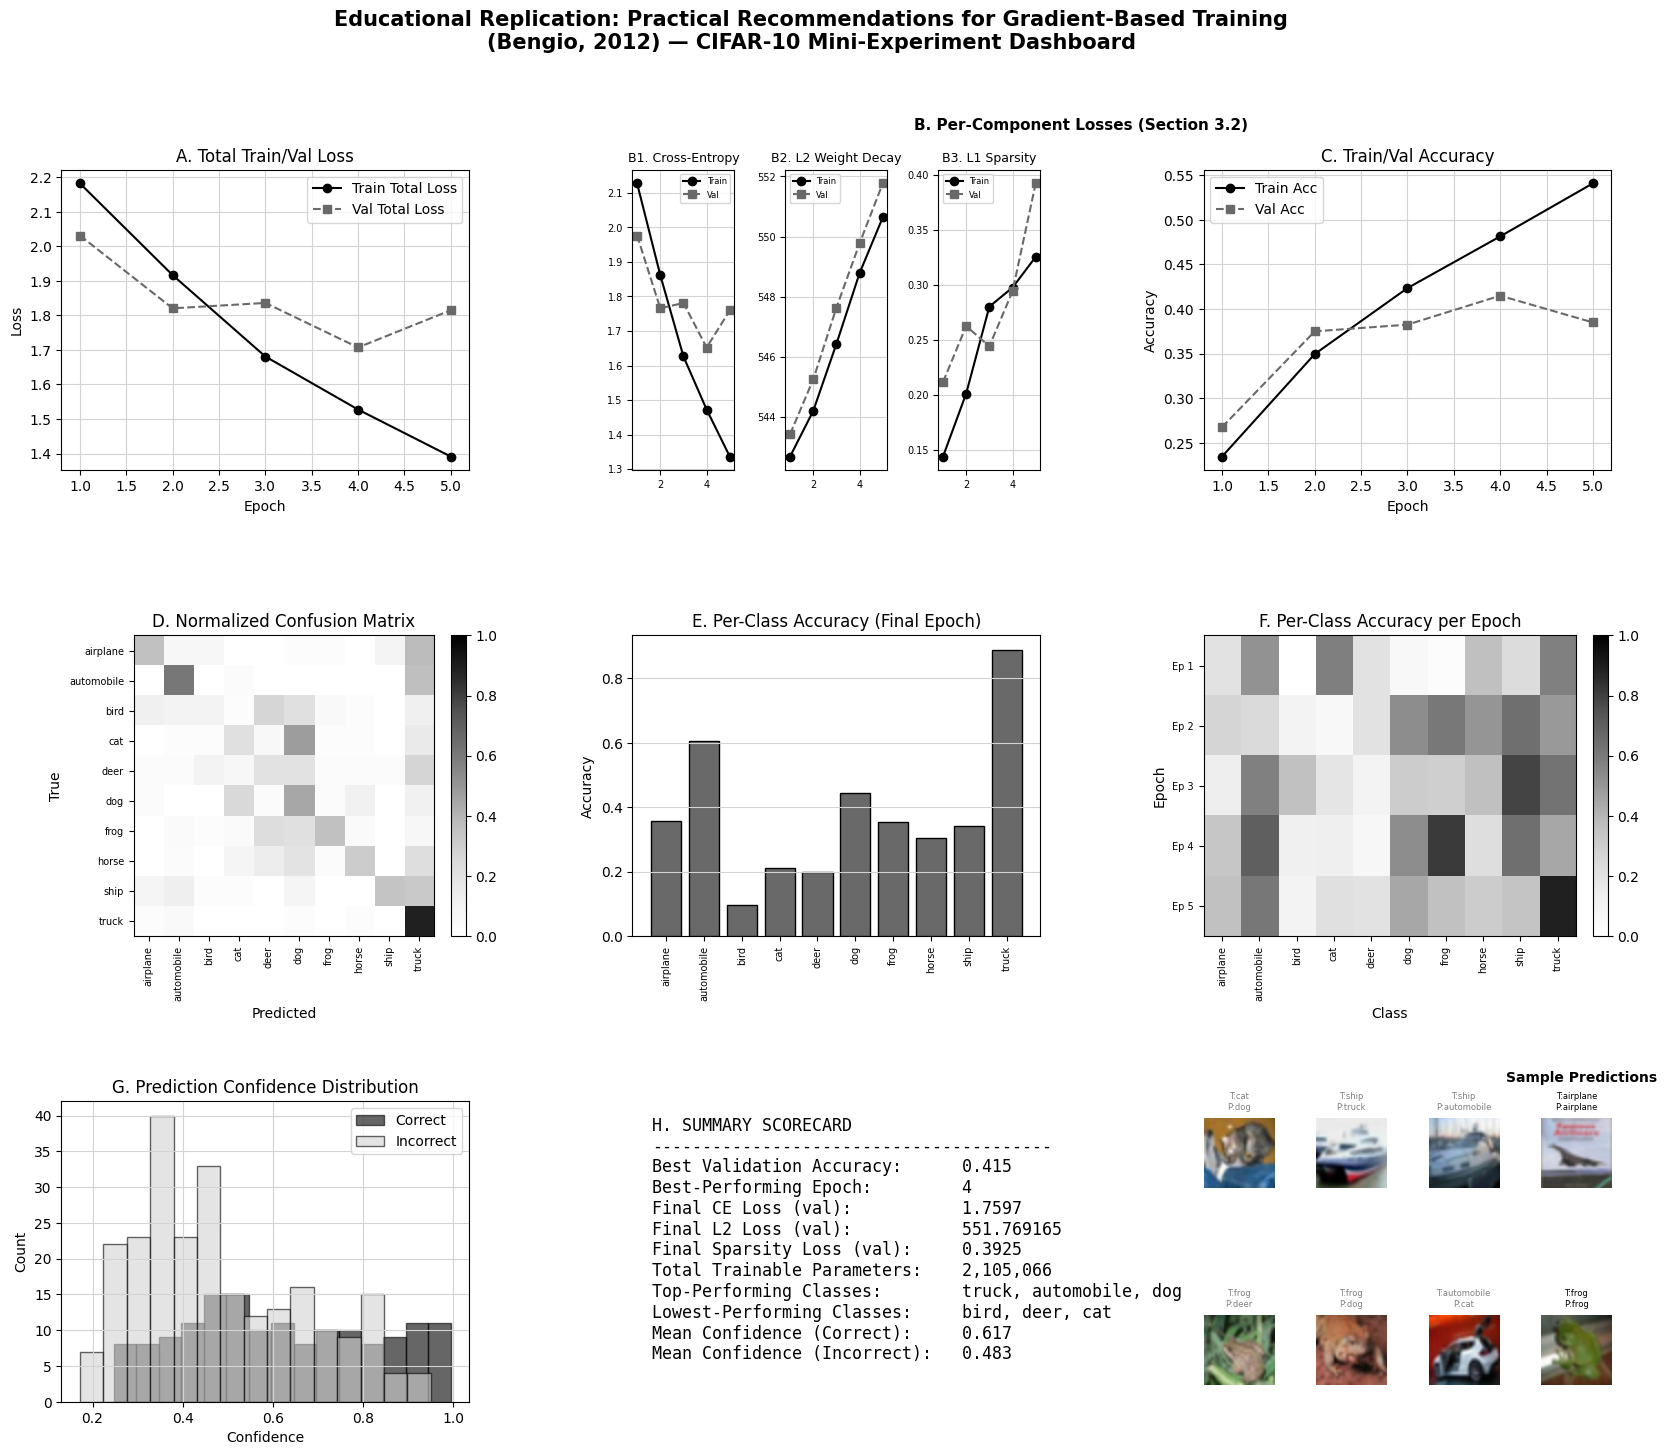

In [18]:
# ============================================================================
# 16. FINAL MULTI-PANEL SUMMARY DASHBOARD (Panels A-H, 3x3 grid)
#     White background, black text throughout, per instructions.
# ============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.titlecolor": "black",
    "legend.labelcolor": "black",
    "grid.color": "lightgrey",
})

fig = plt.figure(figsize=(20, 16), facecolor="white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

epochs_range = list(range(1, NUM_EPOCHS + 1))

# ---------------- Panel A: Total training/validation loss ------------------
axA = fig.add_subplot(gs[0, 0])
axA.set_facecolor("white")
axA.plot(epochs_range, history["train_total_loss"], color="black", marker="o", label="Train Total Loss")
axA.plot(epochs_range, history["val_total_loss"], color="dimgrey", marker="s", linestyle="--", label="Val Total Loss")
axA.set_title("A. Total Train/Val Loss", color="black")
axA.set_xlabel("Epoch", color="black")
axA.set_ylabel("Loss", color="black")
axA.legend(labelcolor="black", facecolor="white")
axA.grid(True, color="lightgrey")
axA.tick_params(colors="black")

# ---------------- Panel B: Component-wise losses (nested sub-panels) -------
gsB = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[0, 1], wspace=0.5)

axB1 = fig.add_subplot(gsB[0, 0])
axB1.set_facecolor("white")
axB1.plot(epochs_range, history["train_ce_loss"], color="black", marker="o", label="Train")
axB1.plot(epochs_range, history["val_ce_loss"], color="dimgrey", marker="s", linestyle="--", label="Val")
axB1.set_title("B1. Cross-Entropy", color="black", fontsize=9)
axB1.tick_params(colors="black", labelsize=7)
axB1.legend(fontsize=6, labelcolor="black", facecolor="white")
axB1.grid(True, color="lightgrey")

axB2 = fig.add_subplot(gsB[0, 1])
axB2.set_facecolor("white")
axB2.plot(epochs_range, history["train_l2_loss"], color="black", marker="o", label="Train")
axB2.plot(epochs_range, history["val_l2_loss"], color="dimgrey", marker="s", linestyle="--", label="Val")
axB2.set_title("B2. L2 Weight Decay", color="black", fontsize=9)
axB2.tick_params(colors="black", labelsize=7)
axB2.legend(fontsize=6, labelcolor="black", facecolor="white")
axB2.grid(True, color="lightgrey")

axB3 = fig.add_subplot(gsB[0, 2])
axB3.set_facecolor("white")
axB3.plot(epochs_range, history["train_sparsity_loss"], color="black", marker="o", label="Train")
axB3.plot(epochs_range, history["val_sparsity_loss"], color="dimgrey", marker="s", linestyle="--", label="Val")
axB3.set_title("B3. L1 Sparsity", color="black", fontsize=9)
axB3.tick_params(colors="black", labelsize=7)
axB3.legend(fontsize=6, labelcolor="black", facecolor="white")
axB3.grid(True, color="lightgrey")

fig.text(0.635, 0.905, "B. Per-Component Losses (Section 3.2)", ha="center",
          fontsize=11, color="black", fontweight="bold")

# ---------------- Panel C: Train/Val accuracy -------------------------------
axC = fig.add_subplot(gs[0, 2])
axC.set_facecolor("white")
axC.plot(epochs_range, history["train_acc"], color="black", marker="o", label="Train Acc")
axC.plot(epochs_range, history["val_acc"], color="dimgrey", marker="s", linestyle="--", label="Val Acc")
axC.set_title("C. Train/Val Accuracy", color="black")
axC.set_xlabel("Epoch", color="black")
axC.set_ylabel("Accuracy", color="black")
axC.legend(labelcolor="black", facecolor="white")
axC.grid(True, color="lightgrey")
axC.tick_params(colors="black")

# ---------------- Panel D: Normalized confusion matrix ----------------------
axD = fig.add_subplot(gs[1, 0])
axD.set_facecolor("white")
im = axD.imshow(cm_normalized, cmap="Greys", vmin=0, vmax=1)
axD.set_title("D. Normalized Confusion Matrix", color="black")
axD.set_xticks(range(NUM_CLASSES))
axD.set_yticks(range(NUM_CLASSES))
axD.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axD.set_yticklabels(CLASS_NAMES, color="black", fontsize=7)
axD.set_xlabel("Predicted", color="black")
axD.set_ylabel("True", color="black")
cbar = plt.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")

# ---------------- Panel E: Per-class accuracy bar chart ---------------------
axE = fig.add_subplot(gs[1, 1])
axE.set_facecolor("white")
axE.bar(range(NUM_CLASSES), final_class_acc, color="dimgrey", edgecolor="black")
axE.set_title("E. Per-Class Accuracy (Final Epoch)", color="black")
axE.set_xticks(range(NUM_CLASSES))
axE.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axE.set_ylabel("Accuracy", color="black")
axE.grid(True, axis="y", color="lightgrey")
axE.tick_params(colors="black")

# ---------------- Panel F: Epoch-wise per-class accuracy heatmap ------------
axF = fig.add_subplot(gs[1, 2])
axF.set_facecolor("white")
imF = axF.imshow(per_class_acc_matrix, cmap="Greys", aspect="auto", vmin=0, vmax=1)
axF.set_title("F. Per-Class Accuracy per Epoch", color="black")
axF.set_xticks(range(NUM_CLASSES))
axF.set_xticklabels(CLASS_NAMES, rotation=90, color="black", fontsize=7)
axF.set_yticks(range(NUM_EPOCHS))
axF.set_yticklabels([f"Ep {e}" for e in epochs_range], color="black", fontsize=7)
axF.set_xlabel("Class", color="black")
axF.set_ylabel("Epoch", color="black")
cbarF = plt.colorbar(imF, ax=axF, fraction=0.046, pad=0.04)
cbarF.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbarF.ax.axes, "yticklabels"), color="black")

# ---------------- Panel G: Confidence distribution histogram ---------------
axG = fig.add_subplot(gs[2, 0])
axG.set_facecolor("white")
axG.hist(confidences_arr[correct_mask], bins=15, alpha=0.6, color="black",
         label="Correct", edgecolor="black")
axG.hist(confidences_arr[~correct_mask], bins=15, alpha=0.6, color="lightgrey",
         label="Incorrect", edgecolor="black")
axG.set_title("G. Prediction Confidence Distribution", color="black")
axG.set_xlabel("Confidence", color="black")
axG.set_ylabel("Count", color="black")
axG.legend(labelcolor="black", facecolor="white")
axG.grid(True, color="lightgrey")
axG.tick_params(colors="black")

# ---------------- Panel H: Text-based summary scorecard ---------------------
axH = fig.add_subplot(gs[2, 1:])
axH.set_facecolor("white")
axH.axis("off")

top_classes_str = ", ".join([CLASS_NAMES[i] for i in top_classes_idx])
low_classes_str = ", ".join([CLASS_NAMES[i] for i in low_classes_idx])

scorecard_text = (
    "H. SUMMARY SCORECARD\n"
    "----------------------------------------\n"
    f"Best Validation Accuracy:      {best_val_acc:.3f}\n"
    f"Best-Performing Epoch:         {best_val_epoch}\n"
    f"Final CE Loss (val):           {history['val_ce_loss'][-1]:.4f}\n"
    f"Final L2 Loss (val):           {history['val_l2_loss'][-1]:.6f}\n"
    f"Final Sparsity Loss (val):     {history['val_sparsity_loss'][-1]:.4f}\n"
    f"Total Trainable Parameters:    {total_params:,}\n"
    f"Top-Performing Classes:        {top_classes_str}\n"
    f"Lowest-Performing Classes:     {low_classes_str}\n"
    f"Mean Confidence (Correct):     {mean_conf_correct:.3f}\n"
    f"Mean Confidence (Incorrect):   {mean_conf_incorrect:.3f}\n"
)

axH.text(0.02, 0.95, scorecard_text, transform=axH.transAxes, fontsize=12,
          color="black", va="top", ha="left", family="monospace")

# ---------------- Sample predictions panel (extra, bottom-right) -----------
gsI = gridspec.GridSpecFromSubplotSpec(2, 4, subplot_spec=gs[2, 2], wspace=0.6, hspace=0.9)
fig.text(0.885, 0.31, "Sample Predictions", ha="center", fontsize=10,
          color="black", fontweight="bold")
for i in range(8):
    ax_img = fig.add_subplot(gsI[i // 4, i % 4])
    ax_img.set_facecolor("white")
    img_display = unnormalize(sample_images[i])
    ax_img.imshow(img_display)
    true_name = CLASS_NAMES[sample_labels[i].item()]
    pred_name = CLASS_NAMES[sample_preds[i].item()]
    color = "black" if true_name == pred_name else "grey"
    ax_img.set_title(f"T:{true_name}\nP:{pred_name}", fontsize=6, color=color)
    ax_img.axis("off")

fig.suptitle(
    "Educational Replication: Practical Recommendations for Gradient-Based Training\n"
    "(Bengio, 2012) — CIFAR-10 Mini-Experiment Dashboard",
    color="black", fontsize=15, fontweight="bold"
)

# ----------------------------------------------------------------------------
# Display inline in Google Colab via an in-memory buffer (no disk saving)
# ----------------------------------------------------------------------------
buf = io.BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Experimental Results Analysis: Educational Replication Dashboard
## (Bengio, 2012) — CIFAR-10 Mini-Experiment

> **Context note**: This dashboard reports a small-scale, 5-epoch educational
> replication (2,000 training / 400 test images) intended to illustrate the
> hyper-parameter and training-criterion concepts from the paper, not to
> reproduce its original large-scale results. Interpretations below are
> scoped accordingly.

---

## Panel A: Total Training/Validation Loss

### Overview
Tracks the combined objective (cross-entropy + λ·L2 + α·sparsity) across 5 epochs for both training and held-out validation data, the primary diagnostic recommended in Section 4.1 of the paper for distinguishing optimization from generalization issues.

### Key Findings
- Training loss decreases monotonically from ~2.18 to ~1.39.
- Validation loss drops sharply in epoch 1–2, then plateaus and mildly oscillates between 1.71–1.84, ending higher than its epoch-4 minimum.
- A growing train–validation gap emerges after epoch 3.

### Discussion
The steadily decreasing training loss confirms that gradient descent is optimizing the criterion correctly (no divergence, consistent with a well-tuned learning-rate schedule). The plateauing and slightly non-monotonic validation loss, however, indicates the onset of overfitting once training loss drops below the validation curve — precisely the diagnostic pattern the paper describes as distinguishing an optimization problem from a generalization problem. Given the very small training subset (2,000 images) relative to model capacity (~2.1M parameters), this divergence is expected and consistent with the paper's guidance that model capacity should be matched to available data and regularization strength.

### Limitations
Only 5 epochs and a small dataset subset limit the reliability of trend extrapolation; the observed plateau may reflect noise from the small validation set (400 samples) rather than a stable generalization ceiling.

---

## Panel B: Component-Wise Losses (B1–B3)

### Overview
Decomposes the total loss into its three additive components — cross-entropy (B1), L2 weight decay (B2), and L1 sparsity penalty (B3) — as motivated by the paper's Bayesian interpretation of regularization (Section 3.2).

### Key Findings
- **B1 (Cross-entropy)**: Declines steadily for training; validation dips then rises after epoch 3, mirroring Panel A's overfitting pattern.
- **B2 (L2 penalty)**: Increases monotonically for both splits (from ~543 to ~552), reflecting growing weight magnitudes as training proceeds.
- **B3 (L1 sparsity)**: Also increases monotonically (~0.15 to ~0.39), indicating hidden-unit activations are becoming less sparse over training.

### Discussion
The rising L2 and sparsity penalties, despite a fixed regularization coefficient, show that the unconstrained cross-entropy gradient dominates the optimization and pushes weights/activations away from zero as the network fits the training data more closely. This is consistent with the paper's discussion of the tension between fitting capacity and regularization: with λ and α both set conservatively (1e-4), regularization exerts a comparatively weak restraining force, allowing weight growth and reduced sparsity to accompany improved training fit. The co-occurrence of increasing sparsity penalty with cross-entropy decrease exemplifies the interaction the paper warns about between sparsity coefficients and other capacity-related hyper-parameters.

### Discussion (continued — validation behavior)
The rise in validation cross-entropy after epoch 3, contemporaneous with continued growth in L2/sparsity penalties, is a plausible early overfitting signature: the paper's early-stopping recommendation (Section 3.1.1) would suggest halting around epoch 3–4, which aligns with the empirical best epoch identified in Panel H.

### Limitations
The regularization coefficients were fixed rather than tuned via validation performance, so the observed weight/activation growth may partly reflect an under-regularized configuration rather than an inherent property of the architecture.

---

## Panel C: Training/Validation Accuracy

### Overview
Reports classification accuracy trajectories, complementing the loss curves with a task-relevant performance metric.

### Key Findings
- Training accuracy rises steadily from ~0.23 to ~0.54.
- Validation accuracy improves from ~0.27 to a peak of ~0.41 at epoch 4, then declines to ~0.38 at epoch 5.
- The train–validation accuracy gap widens from near-zero at epoch 1 to roughly 16 points by epoch 5.

### Discussion
The widening accuracy gap, combined with the loss divergence in Panel A, provides converging evidence of overfitting rather than a stalled optimization. This is a textbook illustration of the paper's assertion that training criterion minimization does not guarantee generalization; capacity (2.1M parameters) substantially exceeds what 2,000 training examples can constrain. The peak validation accuracy at epoch 4 — one epoch before the loss's local minimum reversal — supports the paper's early-stopping heuristic as a practical, inexpensive regularizer.

### Limitations
With only 400 validation examples, accuracy estimates carry considerable sampling variance (a single misclassified batch shifts accuracy by ~1.5–2 points), so the epoch-4 "peak" should be treated as indicative rather than statistically robust.

---

## Panel D: Normalized Confusion Matrix

### Overview
Visualizes per-class prediction distributions at the final epoch, revealing systematic class confusions beyond aggregate accuracy.

### Key Findings
- Strong diagonal dominance for **automobile** and **truck**, indicating high class-specific recall.
- Substantial off-diagonal mass for **bird**, **cat**, and **deer**, which are frequently misclassified as **dog** or **truck**.
- A visible column-wise bias toward **truck**, suggesting the model over-predicts this class.

### Discussion
The asymmetric confusion pattern indicates the model has learned coarse, texture/color-level discriminative features sufficient for high-contrast vehicle classes (trucks, automobiles) but has not learned fine-grained shape features needed to separate visually similar animal classes. The over-prediction of "truck" is consistent with class-conditional loss minimization under limited data: if truck-associated features are more salient or the class is easier to fit within few epochs, the softmax logits may be biased toward it, a common artifact of short training runs with unbalanced representational learning across classes.

### Limitations
With only ~40 test examples per class, per-cell confusion estimates are coarse-grained; individual misclassified examples can visibly perturb off-diagonal proportions.

---

## Panel E & F: Per-Class Accuracy (Final Epoch and Epoch-wise Heatmap)

### Overview
Panel E summarizes final per-class recall; Panel F tracks its evolution across training, offering insight into class-wise learning dynamics.

### Key Findings
- Final accuracy ranges from ~0.10 (bird) to ~0.89 (truck), a substantial spread.
- The heatmap (F) shows automobile and cat achieving relatively high accuracy early (epoch 1) but not necessarily improving monotonically across epochs.
- Truck accuracy increases sharply and consistently by epoch 5, while bird and deer remain persistently low throughout training.

### Discussion
The non-monotonic, class-specific learning trajectories in Panel F illustrate that gradient-based optimization under a shared objective does not allocate learning capacity uniformly across classes — some classes are effectively "won" early while others remain unresolved, a phenomenon linked to class difficulty and training-set class balance. This heterogeneity is important methodologically: it shows that a single aggregate accuracy or loss curve (Panels A–C) can mask substantial per-class instability, reinforcing the value of the paper's general emphasis on detailed monitoring/visualization (Section 4.2) beyond scalar summary statistics.

### Limitations
Given the tiny per-class sample sizes (~40 test images/class), per-class accuracy trajectories are highly susceptible to noise, and apparent "learning" or "regression" for a given class between epochs may reflect only 1–2 sample flips.

---

## Panel G: Prediction Confidence Distribution

### Overview
Compares softmax confidence distributions for correct versus incorrect predictions, a proxy for model calibration.

### Key Findings
- Correct predictions show a confidence distribution skewed toward higher values (peak near 0.35–0.45, moderate weight up to 1.0).
- Incorrect predictions cluster more heavily near 0.3–0.5, with a similarly shaped but left-shifted distribution.
- Considerable overlap exists between the two distributions across the 0.3–0.9 range.

### Discussion
The mean confidence gap reported in Panel H (0.617 correct vs. 0.483 incorrect) indicates the model exhibits some discriminative calibration — correct predictions are, on average, more confident — but the substantial distributional overlap in Panel G shows the model is not well-calibrated in the sense of cleanly separating confident-correct from confident-incorrect cases. This is consistent with a model trained briefly (5 epochs) without any calibration-specific technique (e.g., temperature scaling, label smoothing), and reflects typical early-training behavior where the softmax output has not yet converged to sharply peaked, reliable class-conditional probabilities.

### Limitations
Confidence calibration was not a target metric in the paper being replicated and no calibration-specific evaluation (e.g., ECE, reliability diagrams) was computed; the overlap statistic alone cannot establish whether miscalibration is systematic or an artifact of limited training.

---

## Panel H: Summary Scorecard

### Overview
Consolidates key scalar metrics (best accuracy/epoch, final losses, parameter count, class extremes, confidence statistics) into a single reference panel.

### Key Findings
- Best validation accuracy: 0.415 at epoch 4, one epoch before the final (declining) epoch 5.
- Total trainable parameters: 2,105,066 — large relative to the 2,000-example training set.
- Top classes (truck, automobile, dog) vs. bottom classes (bird, deer, cat) show a > 4× accuracy disparity.
- Mean confidence gap of ~0.13 between correct and incorrect predictions.

### Discussion
The scorecard corroborates the overfitting narrative established in Panels A–C: peak validation performance precedes the final epoch, directly supporting the paper's early-stopping recommendation as a low-cost regularizer. The parameter-to-data ratio (~1,000 parameters per training example) is a plausible primary driver of the observed generalization gap, independent of the specific regularization coefficients chosen. This scorecard format operationalizes the paper's broader emphasis on quantitative, reproducible reporting of training outcomes rather than qualitative or anecdotal assessment.

### Limitations
All scorecard statistics derive from a single training run with fixed hyper-parameters and a single random seed; no variance estimate (e.g., across multiple seeds) is available, limiting claims about the robustness of the identified "best epoch" or class-performance rankings, per the paper's own caution (Section 3.4) that single-configuration results can be affected by random initialization noise.

---

## Overall Synthesis

Collectively, the dashboard's evidence — the widening train/validation gap (Panels A, C), the growing regularization-penalty terms despite conservative coefficients (Panel B), and the early-epoch peak in validation accuracy (Panels C, H) — is internally consistent and jointly supports a single coherent narrative: the model is overfitting a small dataset with a comparatively large-capacity network, and standard mitigations discussed in the paper (early stopping, stronger regularization, more training data) would be expected to narrow the generalization gap. The per-class results (Panels D–F) further reveal that this aggregate overfitting behavior is not uniform across classes, underscoring the paper's broader methodological point that scalar summary metrics should be supplemented with finer-grained diagnostics. Given the deliberately small-scale, illustrative nature of this replication, these findings should be read as a pedagogical demonstration of the paper's principles rather than a quantitative validation of its original empirical claims.

# Related Work Referenced in the Paper

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Hinton, G. E., Osindero, S., Teh, Y.-W. | 2006 | A fast learning algorithm for deep belief nets | Neural Computation | Originated the 2006 Deep Learning breakthrough and greedy layer-wise unsupervised pre-training strategy that motivates the chapter's discussion of pre-training hyper-parameters. |
| Bengio, Y., Lamblin, P., Popovici, D., Larochelle, H. | 2007 | Greedy layer-wise training of deep networks | NIPS'2006 | Introduced the auto-encoder-based greedy layer-wise pre-training approach central to Section 1.1 and the layer-wise hyper-parameter optimization algorithm. |
| Ranzato, M., Poultney, C., Chopra, S., LeCun, Y. | 2007 | Efficient learning of sparse representations with an energy-based model | NIPS'06 | Proposed a sparsifying auto-encoder variant, one of the three foundational 2006-era unsupervised pre-training algorithms discussed in Section 1.1. |
| Bengio, Y. | 2009 | Learning deep architectures for AI | Now Publishers | Provides the theoretical foundation on representation reuse, circuit depth, and expressive power of deep architectures underlying Sections 1.1 and 6.1. |
| Vincent, P., Larochelle, H., Bengio, Y., Manzagol, P.-A. | 2008 | Extracting and composing robust features with denoising autoencoders | ICML 2008 | Introduced the Denoising Auto-Encoder (DAE), directly discussed in Section 1.2 as a robustness-inducing pre-training method. |
| Vincent, P., Larochelle, H., Lajoie, I., Bengio, Y., Manzagol, P.-A. | 2010 | Stacked denoising autoencoders: Learning useful representations in a deep network with a local denoising criterion | J. Machine Learning Res. | Extends DAE training to stacked deep architectures, supporting the paper's treatment of denoising corruption as a regularization mechanism. |
| Rifai, S., Vincent, P., Muller, X., Glorot, X., Bengio, Y. | 2011 | Contracting auto-encoders: Explicit invariance during feature extraction | ICML'2011 | Introduced the Contractive Auto-Encoder (CAE) and its Jacobian-norm penalty, formally presented in Section 1.2 as the counterpart to the DAE. |
| Bengio, Y., Alain, G., Rifai, S. | 2012 | Implicit density estimation by local moment matching to sample from auto-encoders | arXiv:1207.0057 | Establishes the theoretical link between reconstruction error, the Jacobian, and log-density gradient estimation discussed in Section 1.2. |
| Robbins, H., Monro, S. | 1951 | A stochastic approximation method | Annals of Mathematical Statistics | Foundational work establishing stochastic gradient descent, the core optimization algorithm reviewed in Section 2.1. |
| Bottou, L., LeCun, Y. | 2004 | Large-scale on-line learning | NIPS'2003 | Provides the theoretical basis for online/stochastic gradient descent as discussed alongside Robbins and Monro (1951) in Section 2.1. |
| Bottou, L. | 2013 | Large-scale learning with stochastic gradient descent | Neural Networks: Tricks of the Trade, Reloaded | Offers a deeper treatment of SGD convergence and adaptive learning rate heuristics referenced throughout Sections 2.1 and 6.2. |
| Bergstra, J., Bengio, Y. | 2012 | Random search for hyper-parameter optimization | J. Machine Learning Res. | Empirically demonstrates the efficiency advantage of random search over grid search, forming the direct basis for Section 3.4. |
| Bergstra, J., Breuleux, O., Bastien, F., et al. | 2010 | Theano: a CPU and GPU math expression compiler | Proc. Python for Scientific Comp. Conf. (SciPy) | Describes the Theano library used as the symbolic differentiation and GPU computation framework referenced in Sections 2.2 and 5.1. |
| Glorot, X., Bengio, Y. | 2010 | Understanding the difficulty of training deep feedforward neural networks | AISTATS'2010 | Provides the weight initialization formula and analysis of sigmoid saturation issues that directly inform Sections 3.2 and 6.1. |
| Glorot, X., Bordes, A., Bengio, Y. | 2011 | Deep sparse rectifier neural networks | AISTATS'2011 | Empirically validates the rectifier non-linearity's effectiveness in deep networks, cited in Sections 3.2 and 6.1. |
| Nair, V., Hinton, G. E. | 2010 | Rectified linear units improve restricted Boltzmann machines | ICML'2010 | Corroborates the success of rectifying non-linearities referenced alongside Glorot et al. (2011) in Section 6.1. |
| LeCun, Y., Bottou, L., Orr, G. B., Müller, K. | 1998 | Efficient backprop | Neural Networks, Tricks of the Trade | Source of classical weight initialization and second-order learning rate heuristics discussed in Sections 3.2 and 6.2. |
| Erhan, D., Bengio, Y., Courville, A., Manzagol, P.-A., Vincent, P., Bengio, S. | 2010 | Why does unsupervised pre-training help deep learning? | J. Machine Learning Res. | Provides the empirical evidence on local minima and learning trajectory visualization underlying the open questions discussed in Section 6.1. |
| Larochelle, H., Bengio, Y., Louradour, J., Lamblin, P. | 2009 | Exploring strategies for training deep neural networks | J. Machine Learning Res. | Comparative study on hidden layer sizing strategies (pyramid vs. uniform) cited in Section 3.2. |
| Duchi, J., Hazan, E., Singer, Y. | 2011 | Adaptive subgradient methods for online learning and stochastic optimization | J. Machine Learning Res. | Introduces AdaGrad, cited in Section 6.2 as an adaptive learning rate method meriting further evaluation in neural network contexts. |
| Schaul, T., Zhang, S., LeCun, Y. | 2012 | No More Pesky Learning Rates | Technical report | Proposes an adaptive learning rate method aiming to eliminate the learning rate hyper-parameter, discussed in Section 6.2. |
| Martens, J. | 2010 | Deep learning via Hessian-free optimization | ICML'2010 | Represents second-order optimization methods for deep networks, discussed as an alternative to SGD in Section 6.2. |
| Amari, S. | 1998 | Natural gradient works efficiently in learning | Neural Computation | Foundational natural gradient method referenced in Section 6.2 as a theoretically appealing but computationally expensive alternative to SGD. |
| van der Maaten, L., Hinton, G. E. | 2008 | Visualizing data using t-SNE | J. Machine Learning Res. | Provides the dimensionality-reduction visualization technique used for filters, embeddings, and learning trajectories in Section 4.2. |
| Bengio, Y., Louradour, J., Collobert, R., Weston, J. | 2009 | Curriculum learning | ICML'09 | Introduces curriculum learning as a training strategy related to initialization and optimization difficulty, discussed in Section 6.1. |
| Collobert, R., Weston, J., Bottou, L., Karlen, M., Kavukcuoglu, K., Kuksa, P. | 2011 | Natural language processing (almost) from scratch | J. Machine Learning Res. | Demonstrates multi-task parameter/embedding sharing across NLP tasks, cited in Section 5.3 on symbolic variables and multi-task learning. |
| Dauphin, Y., Glorot, X., Bengio, Y. | 2011 | Sampled reconstruction for large-scale learning of embeddings | Proc. ICML'2011 | Source of the sampled reconstruction technique for efficient auto-encoder training on sparse high-dimensional inputs, detailed in Section 5.2. |
| Weston, J., Ratle, F., Collobert, R. | 2008 | Deep learning via semi-supervised embedding | ICML 2008 | Presents an alternative to reconstruction-based unsupervised learning, cited in Sections 5.2 and 6.1 as a local-training-signal method. |